<a href="https://colab.research.google.com/github/ludimilla23/Exercicios_python/blob/main/trabalhoindividualCorrela%C3%A7%C3%A3oeRegress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [66]:
house_data = pd.read_csv('kc_house_data.csv')

In [67]:
house_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,n,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,n,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,n,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,n,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,n,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [68]:
house_data.info()
house_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             9999 non-null   int64  
 1   date           9999 non-null   object 
 2   price          9999 non-null   float64
 3   bedrooms       9999 non-null   int64  
 4   bathrooms      9999 non-null   float64
 5   sqft_living    9999 non-null   int64  
 6   sqft_lot       9999 non-null   int64  
 7   floors         9999 non-null   float64
 8   waterfront     9999 non-null   object 
 9   view           9999 non-null   int64  
 10  condition      9999 non-null   int64  
 11  grade          9999 non-null   int64  
 12  sqft_above     9999 non-null   int64  
 13  sqft_basement  9999 non-null   int64  
 14  yr_built       9999 non-null   int64  
 15  yr_renovated   9999 non-null   int64  
 16  zipcode        9999 non-null   int64  
 17  lat            9999 non-null   float64
 18  long    

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,9.999000e+03,9.999000e+03,9999.000000,9999.000000,9999.000000,9.999000e+03,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,4.549550e+09,5.334366e+05,3.361636,2.061806,2053.088209,1.603696e+04,1.432043,0.238824,3.446345,7.594459,1749.596360,303.491849,1967.274427,91.642364,98077.970297,47.559852,-122.214626,1975.779178,13359.446945
std,2.863859e+09,3.770547e+05,0.916079,0.766884,911.227082,4.504326e+04,0.511869,0.766738,0.666322,1.165901,810.917694,450.852334,27.988987,417.830430,53.943113,0.140048,0.139017,672.264191,27316.491648
min,1.000102e+06,7.500000e+04,0.000000,0.000000,380.000000,5.720000e+02,1.000000,0.000000,1.000000,3.000000,380.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.515000,620.000000,660.000000
25%,2.114001e+09,3.150000e+05,3.000000,1.500000,1410.000000,5.427500e+03,1.000000,0.000000,3.000000,7.000000,1180.000000,0.000000,1950.000000,0.000000,98032.000000,47.461950,-122.326000,1490.000000,5417.500000
50%,3.905010e+09,4.458380e+05,3.000000,2.000000,1890.000000,7.920000e+03,1.000000,0.000000,3.000000,7.000000,1530.000000,0.000000,1969.000000,0.000000,98065.000000,47.573100,-122.231000,1830.000000,7848.000000
75%,7.272001e+09,6.399500e+05,4.000000,2.500000,2500.000000,1.117550e+04,2.000000,0.000000,4.000000,8.000000,2130.000000,600.000000,1990.000000,0.000000,98118.000000,47.679400,-122.126500,2340.000000,10374.500000
max,9.842301e+09,7.700000e+06,11.000000,8.000000,12050.000000,1.651359e+06,3.500000,4.000000,5.000000,13.000000,8860.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,5790.000000,871200.000000


In [69]:
house_num = house_data.select_dtypes(include=np.number)
house_num.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


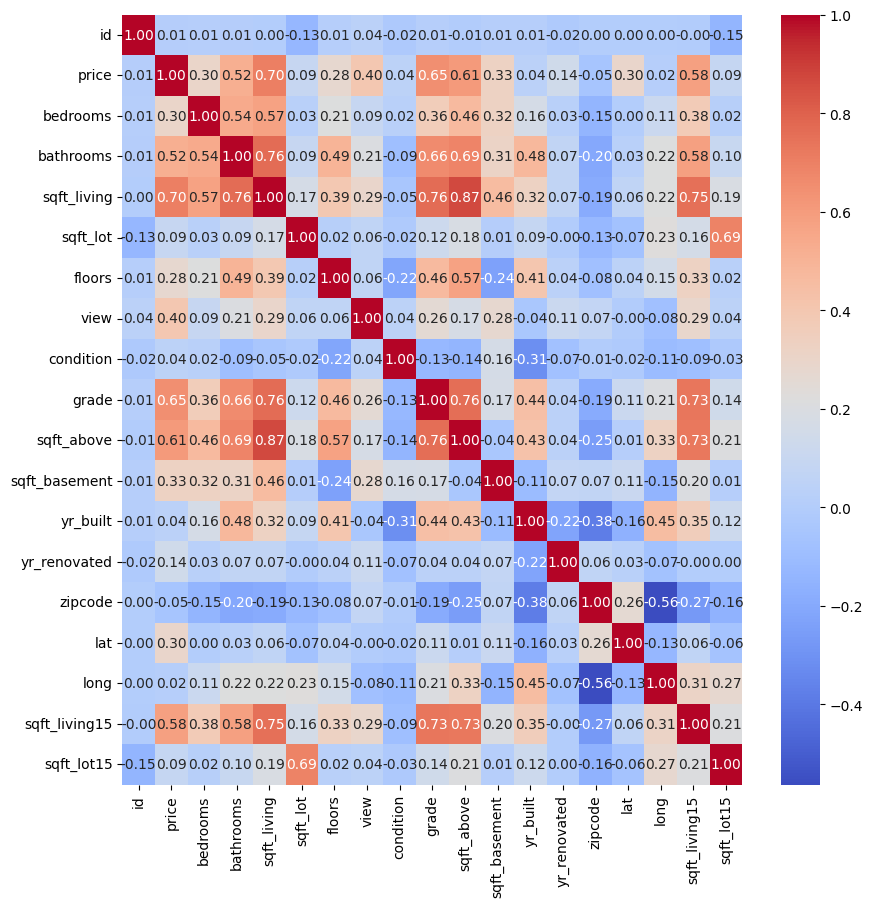

In [70]:
house_num.corr()
plt.figure(figsize=(10,10))
sns.heatmap(house_num.corr(),annot=True,cmap='coolwarm', fmt='.2f')
plt.show()

In [71]:
house_num['bedrooms'].corr(house_num['price'])


0.299207216169182

In [72]:
house_area = house_data[house_data['sqft_living'] >= 2000]
house_area.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,n,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5,7237550310,20140512T000000,1230000.0,4,4.50,5420,101930,1.0,n,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
10,1736800520,20150403T000000,662500.0,3,2.50,3560,9796,1.0,n,0,...,8,1860,1700,1965,0,98007,47.6007,-122.145,2210,8925
15,9297300055,20150124T000000,650000.0,4,3.00,2950,5000,2.0,n,3,...,9,1980,970,1979,0,98126,47.5714,-122.375,2140,4000
21,2524049179,20140826T000000,2000000.0,3,2.75,3050,44867,1.0,n,4,...,9,2330,720,1968,0,98040,47.5316,-122.233,4110,20336


In [73]:
house_area['bedrooms'].corr(house_area['price'])

0.11945220887892764

2-

In [74]:
house_bath = house_data[house_data['bathrooms'] >= 2]
house_bath.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,n,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,n,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,n,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1230000.0,4,4.50,5420,101930,1.0,n,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,n,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819


In [75]:
house_bath['sqft_living'].corr(house_bath['price'])

0.7067107107996192

3-

In [76]:
import statsmodels.api as sm

# Definir variáveis independentes (sqft_living e bathrooms) e a dependente (price)
X = house_data[['sqft_living', 'bathrooms']]
X = sm.add_constant(X)  # Adicionar constante para o modelo
y = house_data['price']

# Criar o modelo de regressão linear
model = sm.OLS(y, X).fit()

# Mostrar o resumo dos resultados
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     4873.
Date:                Fri, 11 Oct 2024   Prob (F-statistic):               0.00
Time:                        02:06:24   Log-Likelihood:            -1.3917e+05
No. Observations:                9999   AIC:                         2.784e+05
Df Residuals:                    9996   BIC:                         2.784e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -4.921e+04   7741.105     -6.357      

In [77]:
# Descobrir o valor máximo de 'bathrooms' no dataset
max_bathrooms = int(house_data['bathrooms'].max())

# Loop para calcular a correlação para cada valor de bathrooms
for i in range(1, max_bathrooms + 1):
    # Filtrar as casas com exatamente 'i' banheiros
    filtered_data = house_data[house_data['bathrooms'] == i]

    # Calcular a correlação entre 'price' e 'sqft_living' para este grupo
    if len(filtered_data) > 1:  # Evitar cálculo se o grupo tiver apenas um valor
        correlation = filtered_data['sqft_living'].corr(filtered_data['price'])
        print(f'Banheiros: {i}, Correlação entre área e preço: {correlation}')
    else:
        print(f'Banheiros: {i}, Correlação: Não disponível (poucos dados)')


Banheiros: 1, Correlação entre área e preço: 0.35952866286208274
Banheiros: 2, Correlação entre área e preço: 0.44694458674958365
Banheiros: 3, Correlação entre área e preço: 0.5690329087491449
Banheiros: 4, Correlação entre área e preço: 0.5844797954618549
Banheiros: 5, Correlação entre área e preço: 0.7472185072000779
Banheiros: 6, Correlação entre área e preço: 1.0
Banheiros: 7, Correlação: Não disponível (poucos dados)
Banheiros: 8, Correlação: Não disponível (poucos dados)


4-

In [78]:
house_area3 = house_data[house_data['sqft_living'] > 3000]
house_area.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,n,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5,7237550310,20140512T000000,1230000.0,4,4.50,5420,101930,1.0,n,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
10,1736800520,20150403T000000,662500.0,3,2.50,3560,9796,1.0,n,0,...,8,1860,1700,1965,0,98007,47.6007,-122.145,2210,8925
15,9297300055,20150124T000000,650000.0,4,3.00,2950,5000,2.0,n,3,...,9,1980,970,1979,0,98126,47.5714,-122.375,2140,4000
21,2524049179,20140826T000000,2000000.0,3,2.75,3050,44867,1.0,n,4,...,9,2330,720,1968,0,98040,47.5316,-122.233,4110,20336


In [79]:
house_area3['condition'].corr(house_area3['price'])

0.10527844723732609

In [80]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             9999 non-null   int64  
 1   date           9999 non-null   object 
 2   price          9999 non-null   float64
 3   bedrooms       9999 non-null   int64  
 4   bathrooms      9999 non-null   float64
 5   sqft_living    9999 non-null   int64  
 6   sqft_lot       9999 non-null   int64  
 7   floors         9999 non-null   float64
 8   waterfront     9999 non-null   object 
 9   view           9999 non-null   int64  
 10  condition      9999 non-null   int64  
 11  grade          9999 non-null   int64  
 12  sqft_above     9999 non-null   int64  
 13  sqft_basement  9999 non-null   int64  
 14  yr_built       9999 non-null   int64  
 15  yr_renovated   9999 non-null   int64  
 16  zipcode        9999 non-null   int64  
 17  lat            9999 non-null   float64
 18  long    

5-

In [81]:
bedroom_3 = house_data[house_data['bedrooms'] >= 3]
bedroom_3.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,n,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,n,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,n,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,n,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1230000.0,4,4.50,5420,101930,1.0,n,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930


In [82]:
corr_lat_price = bedroom_3['lat'].corr(bedroom_3['price'])
corr_long_price = bedroom_3['long'].corr(bedroom_3['price'])
print(corr_lat_price)
print(corr_long_price)


0.31255514248432165
-0.0072753069929269365


6-

In [83]:
house_data['waterfront'].unique()

array(['n', 'y'], dtype=object)

In [84]:
house_data['waterfront'].value_counts()

,count
waterfront,
n,9920
y,79


In [85]:
group_yes = house_data[house_data['waterfront'] == 'y']['price']  # Preços das casas à beira da água
group_no = house_data[house_data['waterfront'] == 'n']['price']    # Preços das casas não à beira da água

import scipy.stats as stats

f_statistic, p_value = stats.f_oneway(group_yes, group_no)

print(f'Estatística F: {f_statistic}')
print(f'Valor p: {p_value}')

alpha = 0.05
if p_value < alpha:
    print('Há uma diferença significativa entre os preços dos grupos.')
else:
    print('Não há diferença significativa entre os preços dos grupos.')

Estatística F: 964.5733248785584
Valor p: 2.97380815121432e-202
Há uma diferença significativa entre os preços dos grupos.


7-

In [86]:
df_car = pd.read_csv('car_price.csv')
df_car.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [87]:
df_car.info()
df_car.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1874 non-null   object 
 1   Model               1874 non-null   object 
 2   Price               1874 non-null   int64  
 3   Year                1874 non-null   int64  
 4   Kilometer           1874 non-null   int64  
 5   Fuel Type           1874 non-null   object 
 6   Transmission        1874 non-null   object 
 7   Location            1874 non-null   object 
 8   Color               1874 non-null   object 
 9   Owner               1874 non-null   object 
 10  Seller Type         1874 non-null   object 
 11  Engine              1874 non-null   object 
 12  Max Power           1874 non-null   object 
 13  Max Torque          1874 non-null   object 
 14  Drivetrain          1874 non-null   object 
 15  Length              1874 non-null   float64
 16  Width 

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,1.874000e+03,1874.000000,1.874000e+03,1874.000000,1874.000000,1874.000000,1874.000000,1874.000000
mean,1.718279e+06,2016.713447,5.317814e+04,4281.512807,1767.886339,1588.967983,5.295091,52.217343
std,2.426090e+06,3.138477,5.878833e+04,436.220747,131.344883,134.627659,0.807008,15.167250
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1213.000000,2.000000,15.000000
25%,5.000000e+05,2015.000000,2.801975e+04,3985.000000,1695.000000,1485.000000,5.000000,42.000000
50%,8.424995e+05,2017.000000,4.879750e+04,4360.000000,1770.000000,1544.000000,5.000000,50.000000
75%,1.908250e+06,2019.000000,7.100000e+04,4620.000000,1831.000000,1670.750000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


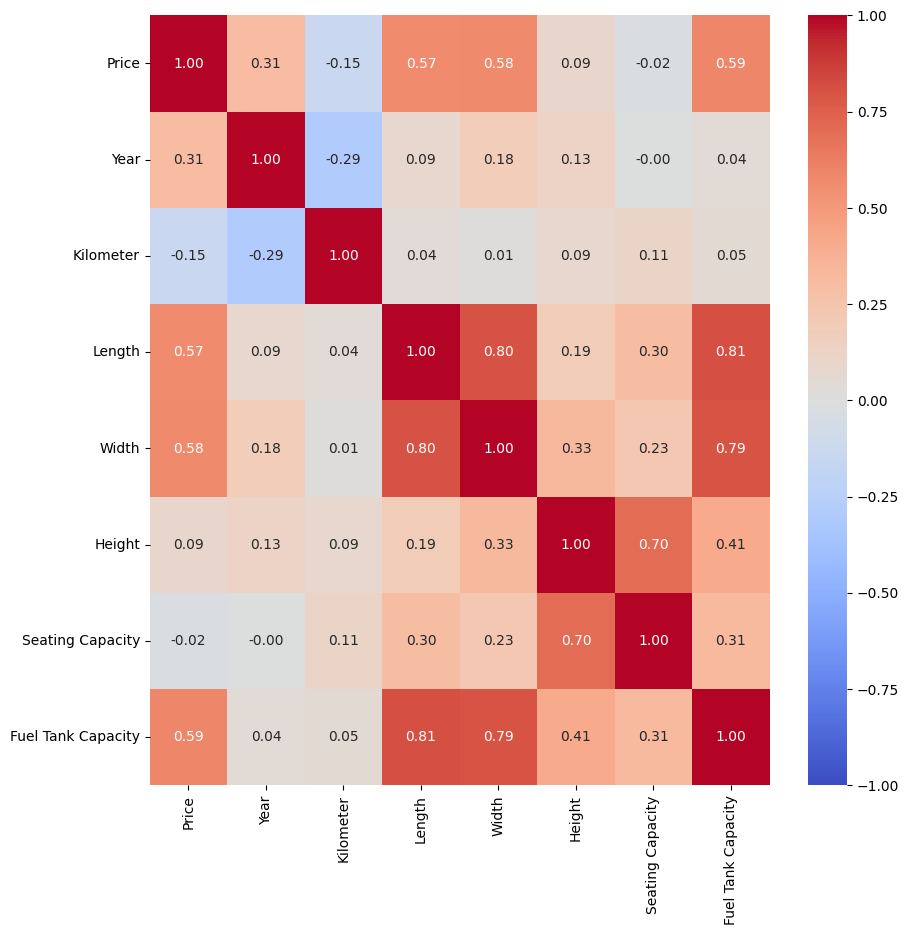

In [88]:
df_num = df_car.select_dtypes(include=np.number)
plt.figure(figsize=(10,10))
sns.heatmap(df_num.corr(),annot=True,cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.show()

8-

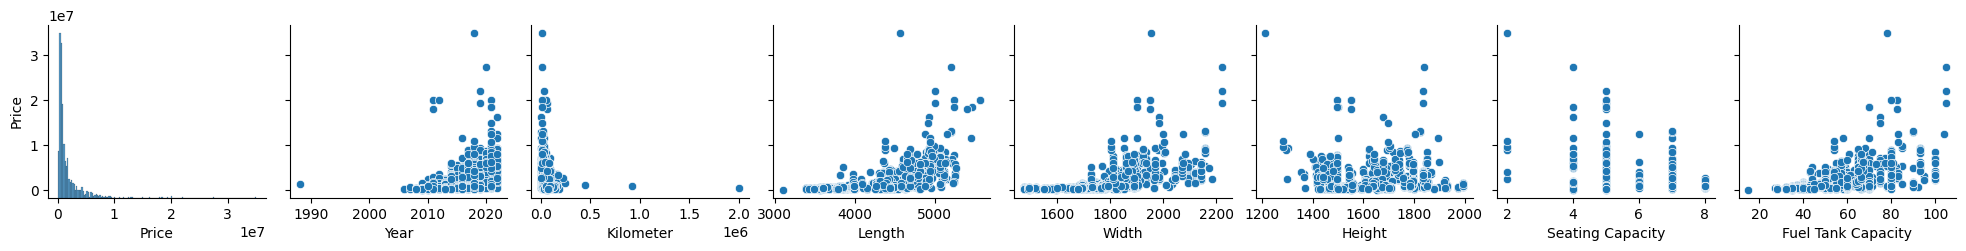

In [89]:
sns.pairplot(df_num, x_vars=df_num, y_vars='Price', kind='scatter')

# Exibir os gráficos
plt.show()

9-

In [90]:
x= df_num['Fuel Tank Capacity']
y= df_num['Price']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

y_pred = model.predict(x)  # Valores previstos
residuals = model.resid  #

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     979.6
Date:                Fri, 11 Oct 2024   Prob (F-statistic):          2.59e-173
Time:                        02:06:27   Log-Likelihood:                -29815.
No. Observations:                1874   AIC:                         5.963e+04
Df Residuals:                    1872   BIC:                         5.965e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -3.177e+06   1.63

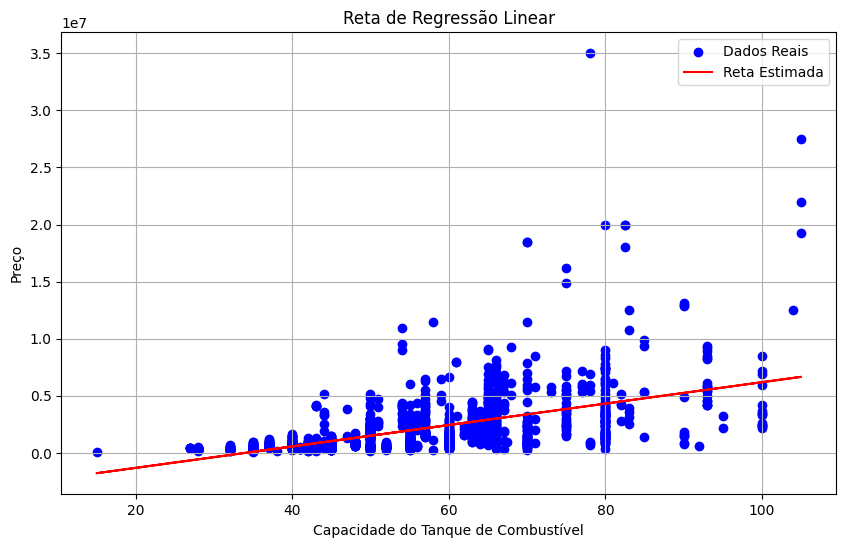

In [91]:
plt.figure(figsize=(10, 6))
plt.scatter(df_num['Fuel Tank Capacity'], df_num['Price'], color='blue', label='Dados Reais')
plt.plot(df_num['Fuel Tank Capacity'], model.predict(x), color='red', label='Reta Estimada')
plt.title('Reta de Regressão Linear')
plt.xlabel('Capacidade do Tanque de Combustível')
plt.ylabel('Preço')
plt.legend()
plt.grid()
plt.show()

10-

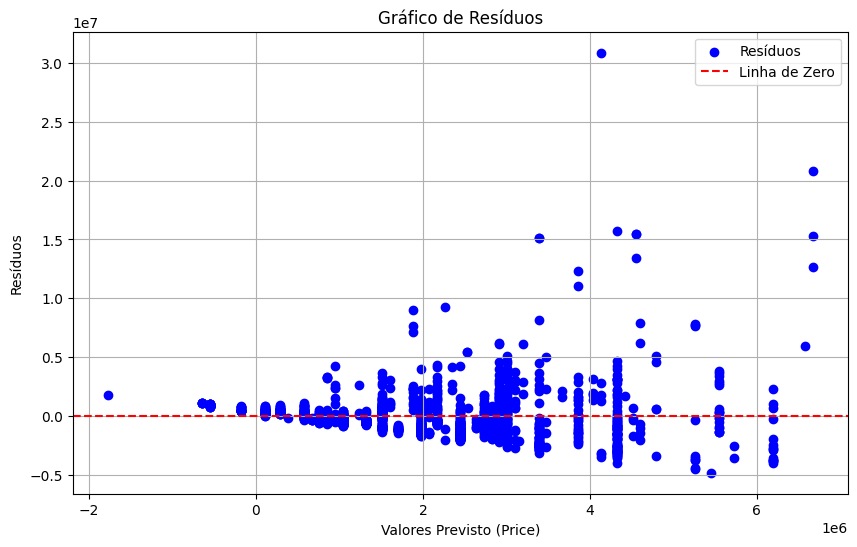

In [92]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='blue', label='Resíduos')
plt.axhline(0, color='red', linestyle='--', label='Linha de Zero')
plt.title('Gráfico de Resíduos')
plt.xlabel('Valores Previsto (Price)')
plt.ylabel('Resíduos')
plt.legend()
plt.grid()
plt.show()

11-

In [93]:
X = df_num[['Fuel Tank Capacity', 'Length', 'Width']]
X = sm.add_constant(X)
y = df_num['Price']
model = sm.OLS(y, X).fit()
print(model.summary())
residuos = model.resid

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     391.4
Date:                Fri, 11 Oct 2024   Prob (F-statistic):          2.79e-197
Time:                        02:06:28   Log-Likelihood:                -29753.
No. Observations:                1874   AIC:                         5.951e+04
Df Residuals:                    1870   BIC:                         5.954e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               -1.21e+07   8.16

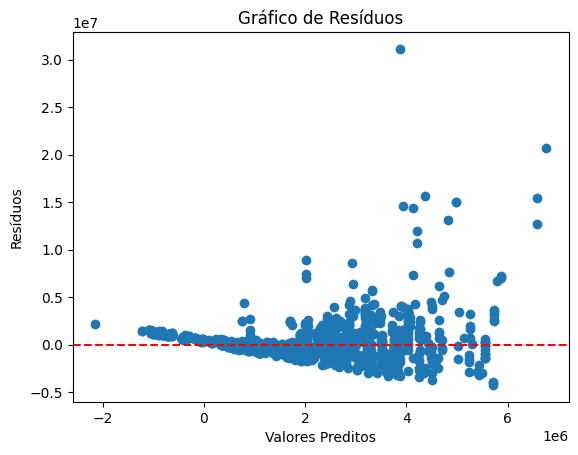

In [94]:
plt.scatter(model.fittedvalues, residuos)
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()
